# Week 6 Day 4 Lab


In [2]:
# run this cell first!

import numpy as np
np.random.seed(42)
import matplotlib.pyplot as plt

### Problem 1
Generate 100,000 samples using `np.random.uniform(0,1)` and compute the average so far at each sample. Plot the data. What do you notice?

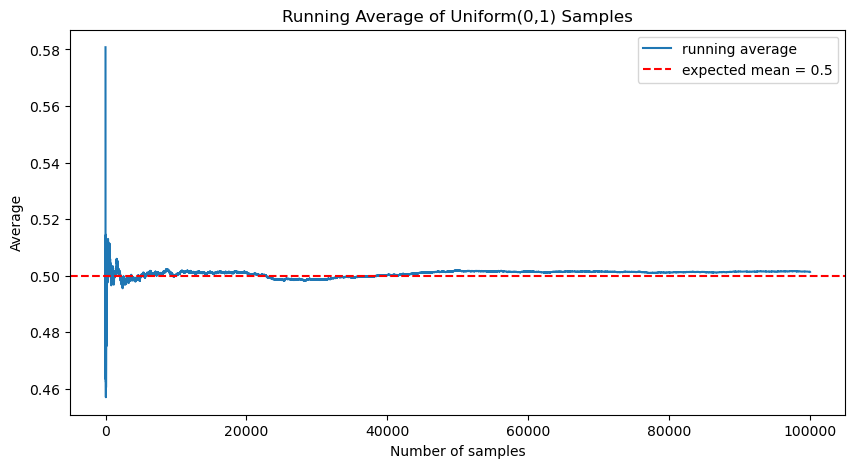

In [7]:
samples = np.random.uniform(0,1,100000)
running_avg = np.cumsum(samples) / np.arange(1, len(samples) + 1)
plt.figure(figsize=(10, 5))
plt.plot(running_avg, label="running average")
plt.axhline(0.5, color = "red", linestyle="--", label = "expected mean = 0.5")
plt.xlabel("Number of samples")
plt.ylabel("Average")
plt.title("Running Average of Uniform(0,1) Samples")
plt.legend()
plt.show()

### Problem 2
We want to compute $\int_0^1 x^2dx$. To do so, generate random points between 0 and 1. Accept them if they are below and reject them if they are above. Compute the average of the accepted values and plot the accepted vs rejected points.

Estimated Integral= 0.3335
True Integral = 0.3333333333333333


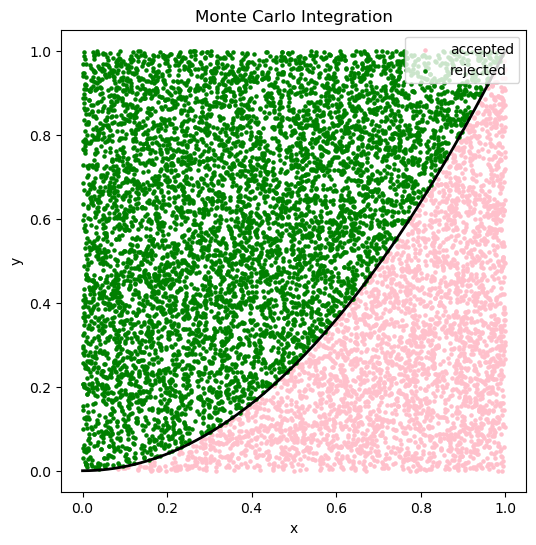

In [10]:
N=10000
x=np.random.uniform(0,1,N)
y=np.random.uniform(0,1,N)
f = x**2
accepted = y <= f
integral = np.mean(accepted)
print("Estimated Integral=", integral)
print("True Integral =", 1/3)
plt.figure(figsize=(6,6))
plt.scatter(x[accepted], y[accepted],s=5, color = "pink", label = "accepted")
plt.scatter(x[~accepted], y[~accepted],s=5, color = "green", label = "rejected")
x_plot = np.linspace(0,1,200)
plt.plot(x_plot, x_plot**2, color="black", linewidth=2)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Monte Carlo Integration")
plt.legend()
plt.show()

### Problem 3 
Write a function that will do Problem 2 for any function and bounds.

In [11]:
def monte_carlo_integral(func, a, b, N=10000, plot="True"):
    x=np.random.uniform(a, b, N)
    fx = func(x)
    ymax = np.max(fx)
    y = np.random.uniform(0, ymax, N)
    accepted = y <= fx
    area = (b - a) *ymax
    estimate = area * np.mean(accepted)
    if plot:
        plt.figure(figsize=(6,6))
        plt.scatter(x[accepted], y[accepted],s=5, color = "pink", label = "accepted")
        plt.scatter(x[~accepted], y[~accepted],s=5, color = "green", label = "rejected")
        x_plot = np.linspace(0,1,300)
        plt.plot(x_plot, x_plot**2, color="black", linewidth=2)
        plt.xlabel("x")
        plt.ylabel("y")
        plt.title("Monte Carlo Integration")
        plt.legend()
        plt.show()
    return estimate

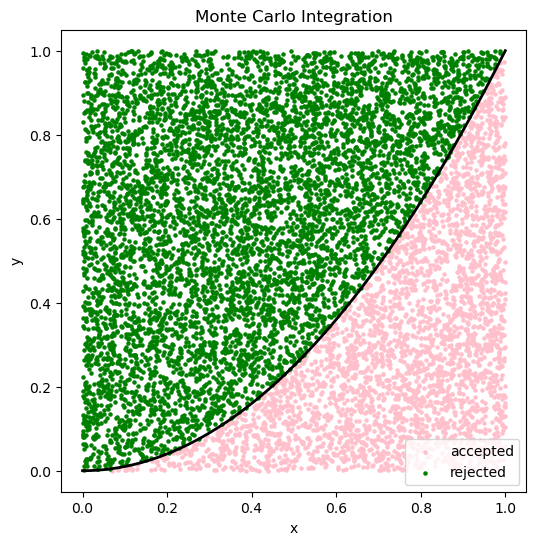

Estimated Integral: 0.3319176361336137
Exact Value: 0.3333333333333333


In [12]:
estimate = monte_carlo_integral(lambda x: x**2, 0, 1, N=10000)
print("Estimated Integral:", estimate)
print("Exact Value:", 1/3)

### Problem 4

Estimate $\pi$ using one of the functions from lecture with:

- 1,000 samples
- 10,000 samples
- 100,000 samples

Compare the results with the true value of $\pi$.

In [13]:
def estimate_pi(N):
    x =np.random.uniform(-1,1,N)
    y =np.random.uniform(-1,1,N)
    inside = x**2 + y**2 <=1
    return 4 *np.mean(inside)
sample_sizes =[1000, 10000, 100000]
for N in sample_sizes:
    pi_est = estimate_pi(N)
    print(f"Samples = {N}")
    print(f"Estimated π = {pi_est}")
    print(f"True π      = {np.pi}")
    print(f"Error        = {abs(pi_est - np.pi):.6f}\n")

Samples = 1000
Estimated π = 3.176
True π      = 3.141592653589793
Error        = 0.034407

Samples = 10000
Estimated π = 3.1472
True π      = 3.141592653589793
Error        = 0.005607

Samples = 100000
Estimated π = 3.14188
True π      = 3.141592653589793
Error        = 0.000287

